# Qwen3-VL-4B Fine-tuning — Hotel Room Defect Detection
QLoRA fine-tune via Unsloth. Run cells top to bottom.

In [9]:
import json
import re
import sys
import random
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from datasets import Dataset
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from qwen_vl_utils import process_vision_info

# Notebook lives in training/ — go one level up to get project root
ROOT       = Path(".").resolve().parent
CLEAN_DIR  = ROOT / "data" / "clean"
MESSY_DIR  = ROOT / "data" / "messy"
OUTPUT_DIR = ROOT / "outputs" / "lora_adapter"

sys.path.insert(0, str(ROOT))

## Config

In [10]:
MODEL_ID    = "unsloth/Qwen3-VL-4B-Instruct-unsloth-bnb-4bit"

LORA_R      = 32
LORA_ALPHA  = 32
LR          = 2e-4
EPOCHS      = 5
BATCH_SIZE  = 2
GRAD_ACCUM  = 4
MAX_SEQ_LEN = 2048
EVAL_SPLIT  = 0.15

MIN_PIXELS  = 256 * 28 * 28
MAX_PIXELS  = 512 * 28 * 28

QUESTION = (
    "Inspect this hotel room for cleanliness defects. "
    "Respond ONLY with valid JSON using this schema: "
    '{"clean": true/false, "defects": [{"object": "...", "type": "...", "description": "..."}]}'
)

## Build Dataset

In [11]:
def make_messy_sample(img_path, defects):
    defect_list = [
        {"object": d["object"], "type": d["label"], "description": d["prompt"]}
        for d in defects
    ]
    answer = json.dumps({"clean": False, "defects": defect_list})
    return {"messages": [
        {"role": "user", "content": [
            {"type": "image", "image": str(img_path)},
            {"type": "text",  "text": QUESTION},
        ]},
        {"role": "assistant", "content": [{"type": "text", "text": answer}]},
    ]}

def make_clean_sample(img_path):
    answer = json.dumps({"clean": True, "defects": []})
    return {"messages": [
        {"role": "user", "content": [
            {"type": "image", "image": str(img_path)},
            {"type": "text",  "text": QUESTION},
        ]},
        {"role": "assistant", "content": [{"type": "text", "text": answer}]},
    ]}

manifest = json.loads((MESSY_DIR / "manifest.json").read_text())
rows = []

for img_name, variants in manifest.items():
    for variant in variants:
        out_path = MESSY_DIR / variant["output"]
        if out_path.exists():
            rows.append(make_messy_sample(out_path, variant["defects"]))

for img_path in sorted(CLEAN_DIR.glob("*.jpg")):
    rows.append(make_clean_sample(img_path))

random.shuffle(rows)
n_eval   = max(1, int(len(rows) * EVAL_SPLIT))
train_ds = Dataset.from_list(rows[n_eval:])
eval_ds  = Dataset.from_list(rows[:n_eval])

print(f"Train: {len(train_ds)}  Eval: {len(eval_ds)}")

Train: 742  Eval: 130


## Load Model + LoRA

In [12]:
model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_ID,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
    max_seq_length=MAX_SEQ_LEN,
)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=False,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0,
    bias="none",
    use_rslora=False,
)

print("Model loaded.")

==((====))==  Unsloth 2026.2.1: Fast Qwen3_Vl patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 5070 Ti. Num GPUs = 1. Max memory: 15.92 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Model loaded.


## Train

In [13]:
FastVisionModel.for_training(model)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    args=SFTConfig(
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        num_train_epochs=EPOCHS,
        learning_rate=LR,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        weight_decay=0.01,
        max_grad_norm=0.3,
        bf16=torch.cuda.is_bf16_supported(),
        fp16=not torch.cuda.is_bf16_supported(),
        optim="adamw_8bit",
        max_seq_length=MAX_SEQ_LEN,
        eval_strategy="steps",
        eval_steps=50,
        save_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        output_dir=str(OUTPUT_DIR / "checkpoints"),
        report_to="none",
        logging_steps=10,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        remove_unused_columns=False,
    ),
)

trainer.train()

Unsloth: Model does not have a default image size - using 512


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 742 | Num Epochs = 5 | Total steps = 465
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 66,060,288 of 4,503,876,096 (1.47% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
50,0.086400,0.089100
100,0.053800,0.063515
150,0.047200,0.054388
200,0.036000,0.049636
250,0.037500,0.048229
300,0.022600,0.049304
350,0.023200,0.049219
400,0.013000,0.055829
450,0.012400,0.057479


TrainOutput(global_step=465, training_loss=0.10833106672251096, metrics={'train_runtime': 1041.5204, 'train_samples_per_second': 3.562, 'train_steps_per_second': 0.446, 'total_flos': 2.798980806171648e+16, 'train_loss': 0.10833106672251096, 'epoch': 5.0})

## Save Adapter

In [14]:
model.save_pretrained(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))
print(f"Adapter saved to {OUTPUT_DIR}")

Adapter saved to C:\Users\ranen\Projects\roomaudit\outputs\lora_adapter


## Training Curves

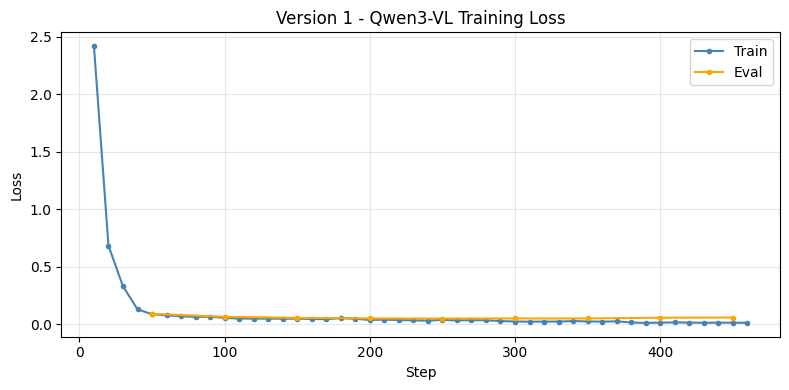

In [15]:
log = trainer.state.log_history

train_steps = [e["step"] for e in log if "loss" in e and "eval_loss" not in e]
train_loss  = [e["loss"] for e in log if "loss" in e and "eval_loss" not in e]
eval_steps  = [e["step"] for e in log if "eval_loss" in e]
eval_loss   = [e["eval_loss"] for e in log if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_steps, train_loss, label="Train", color="steelblue", marker="o", markersize=3)
ax.plot(eval_steps,  eval_loss,  label="Eval",  color="orange",   marker="o", markersize=3)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Version 1 - Qwen3-VL Training Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "loss_curve.png"), dpi=150)
plt.show()

## Eval Inference + Final Metrics

In [16]:
FastVisionModel.for_inference(model)

y_true, y_pred = [], []

def clean_messages(messages):
    # Arrow serialization inserts None for missing keys across content items — strip them
    result = []
    for msg in messages:
        clean_content = [
            {k: v for k, v in item.items() if v is not None}
            for item in msg["content"]
        ]
        result.append({**msg, "content": clean_content})
    return result

for sample in eval_ds:
    gt = json.loads(sample["messages"][1]["content"][0]["text"])
    gt_clean = gt["clean"]

    messages = clean_messages([sample["messages"][0]])
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = tokenizer(
        text=[text], images=image_inputs, padding=True, return_tensors="pt"
    ).to("cuda")

    out_ids = model.generate(
        **inputs, max_new_tokens=256,
        do_sample=True, temperature=0.1, repetition_penalty=1.05,
    )
    gen_ids     = [o[len(i):] for i, o in zip(inputs.input_ids, out_ids)]
    output_text = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)[0].strip()

    try:
        match = re.search(r"\{.*\}", output_text, re.DOTALL)
        pred       = json.loads(match.group()) if match else {}
        pred_clean = pred.get("clean", True)
    except Exception:
        pred_clean = True

    y_true.append(0 if gt_clean else 1)
    y_pred.append(0 if pred_clean else 1)

print(f"Eval samples: {len(y_true)}")

Eval samples: 130


Accuracy:  0.769
Precision: 0.769
Recall:    1.000
F1:        0.870


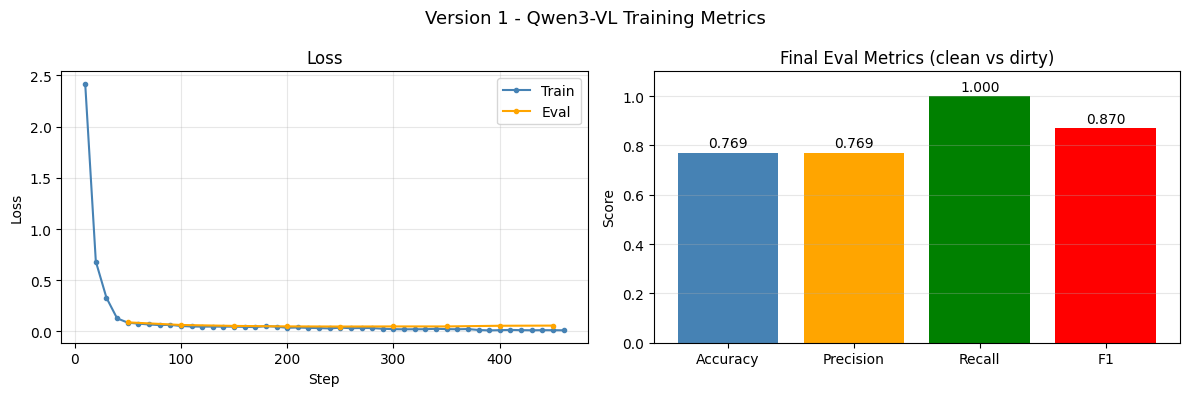

In [17]:
tp = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)
fp = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)
tn = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)
fn = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)

accuracy  = (tp + tn) / len(y_true) if y_true else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Version 1 - Qwen3-VL Training Metrics", fontsize=13)

# Loss curves
axes[0].plot(train_steps, train_loss, label="Train", color="steelblue", marker="o", markersize=3)
axes[0].plot(eval_steps,  eval_loss,  label="Eval",  color="orange",   marker="o", markersize=3)
axes[0].set_title("Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Final metrics bar chart
labels  = ["Accuracy", "Precision", "Recall", "F1"]
values  = [accuracy, precision, recall, f1]
colors  = ["steelblue", "orange", "green", "red"]
bars    = axes[1].bar(labels, values, color=colors)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Final Eval Metrics (clean vs dirty)")
axes[1].set_ylabel("Score")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "metrics.png"), dpi=150)
plt.show()